Step 1: Loading and Pre-processing Data...
11490434/11490434 ━━━━━━━━━━━━━━━━━━━━ 2s 0us/step
Dataset ready. Training shape: (60000, 28, 28, 1)

Step 2: Building the Encoder (The Squeezer)...


Model: "Encoder"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer (InputLayer)        │ (None, 28, 28, 1)      │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 28, 28, 16)     │           160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 14, 14, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 14, 14, 8)      │         1,160 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 392)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ latent_vector (Dense)           │ (None, 16)             │         6,288 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 7,608 (29.72 KB)

 Trainable params: 7,608 (29.72 KB)

...

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ input_layer_1 (InputLayer)      │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 392)            │         6,664 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ reshape (Reshape)               │ (None, 7, 7, 8)        │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose                │ (None, 14, 14, 8)      │           584 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_transpose_1              │ (None, 28, 28, 16)     │         1,168 │
│ (Conv2DTranspose)               │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 28, 28, 1)      │           145 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,561 (33.44 KB)

 Trainable params: 8,561 (33.44 KB)

 Non-trainable params: 0 (0.00 B)


Step 4: Training. The model is learning the best way to compress digits...
Epoch 1/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 34s 70ms/step - loss: 0.0602 - val_loss: 0.0301
Epoch 2/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.0225 - val_loss: 0.0184
Epoch 3/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.0177 - val_loss: 0.0163
Epoch 4/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 70ms/step - loss: 0.0161 - val_loss: 0.0152
Epoch 5/5
469/469 ━━━━━━━━━━━━━━━━━━━━ 41s 71ms/step - loss: 0.0152 - val_loss: 0.0145

Step 5: Visualizing Results...
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 50ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 56ms/step


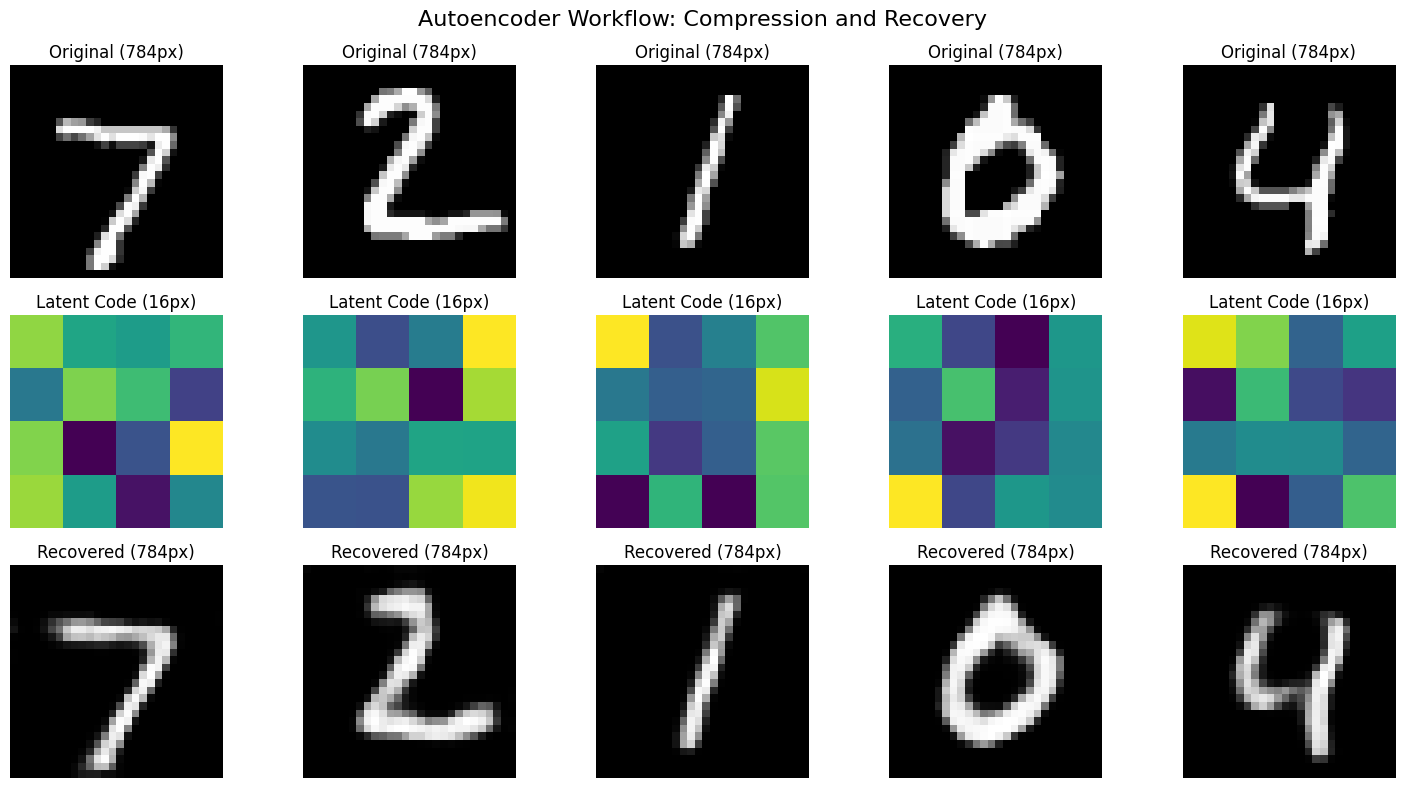


Tutorial Summary:
- Original Dimensions: 28x28 = 784
- Bottleneck Dimensions: 16
- Data reduction: 49.0x compression.
- The Decoder successfully 'guessed' the missing 98% of the data using learned patterns!


In [ ]:
import tensorflow as tf
from tensorflow.keras import layers, models
import numpy as np
import matplotlib.pyplot as plt

# =================================================================
# 1. DATA PREPARATION: DEFINING THE VECTOR SPACE
# =================================================================
print("Step 1: Loading and Pre-processing Data...")

# Load MNIST - We only need the images (x), not the labels (y)
# because an autoencoder learns from the data itself (unsupervised).
(x_train, _), (x_test, _) = tf.keras.datasets.mnist.load_data()

# Normalize pixel values to [0, 1] for better neural network convergence.
x_train = x_train.astype('float32') / 255.
x_test = x_test.astype('float32') / 255.

# Reshape to (Batch, Height, Width, Channels).
# Matrix Algebra Note: This adds a depth dimension of 1 for grayscale.
x_train = np.reshape(x_train, (len(x_train), 28, 28, 1))
x_test = np.reshape(x_test, (len(x_test), 28, 28, 1))

print(f"Dataset ready. Training shape: {x_train.shape}")

# =================================================================
# 2. THE ENCODER: THE COMPRESSION MANIFOLD
# =================================================================
print("\nStep 2: Building the Encoder (The Squeezer)...")

encoder_input = layers.Input(shape=(28, 28, 1))

# Feature Extraction: Using 3x3 kernels to find edges and curves.
# MaxPooling reduces spatial dimensions: 28x28 -> 14x14 -> 7x7.
x = layers.Conv2D(16, (3, 3), activation='relu', padding='same')(encoder_input)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

x = layers.Conv2D(8, (3, 3), activation='relu', padding='same')(x)
x = layers.MaxPooling2D((2, 2), padding='same')(x)

# The Bottleneck: Squashing the 3D tensor into a 1D 'Latent Vector'.
# We go from 7*7*8 = 392 values down to just 16 "important parameters".
shape_before_flattening = tf.keras.backend.int_shape(x)[1:]
x = layers.Flatten()(x)
latent_space = layers.Dense(16, name="latent_vector")(x)

encoder = models.Model(encoder_input, latent_space, name="Encoder")
encoder.summary() # Prints the architecture and parameter counts.

# =================================================================
# 3. THE DECODER: RECOVERING THE SIGNAL
# =================================================================
print("\nStep 3: Building the Decoder (The Recovery)...")

decoder_input = layers.Input(shape=(16,))

# Inverse Flattening: Mapping 16 parameters back to 392 neurons.
num_elements = int(np.prod(shape_before_flattening))
x = layers.Dense(num_elements)(decoder_input)
x = layers.Reshape(shape_before_flattening)(x)

# Up-sampling: Transposed convolutions "hallucinate" the missing pixels.
# This recovers the spatial resolution: 7x7 -> 14x14 -> 28x28.
x = layers.Conv2DTranspose(8, (3, 3), strides=2, activation='relu', padding='same')(x)
x = layers.Conv2DTranspose(16, (3, 3), strides=2, activation='relu', padding='same')(x)

# Output Layer: Uses 'sigmoid' to ensure pixel values are between 0 and 1.
decoder_output = layers.Conv2D(1, (3, 3), activation='sigmoid', padding='same')(x)

decoder = models.Model(decoder_input, decoder_output, name="Decoder")
decoder.summary()

# =================================================================
# 4. FULL AUTOENCODER: TRAINING THE BRIDGE
# =================================================================
autoencoder = models.Model(encoder_input, decoder(encoder(encoder_input)))

# We use 'mse' (Mean Squared Error) to minimize the distance
# between the original image A and reconstructed image A'.
autoencoder.compile(optimizer='adam', loss='mse')

print("\nStep 4: Training. The model is learning the best way to compress digits...")
history = autoencoder.fit(x_train, x_train,
                          epochs=5,
                          batch_size=128,
                          validation_data=(x_test, x_test),
                          verbose=1)

# =================================================================
# 5. VISUALIZATION: PEEKING INTO THE BOTTLENECK
# =================================================================
print("\nStep 5: Visualizing Results...")

# Take some test digits
n = 5
test_samples = x_test[:n]
latent_vectors = encoder.predict(test_samples)
decoded_imgs = decoder.predict(latent_vectors)

plt.figure(figsize=(15, 8))

for i in range(n):
    # --- Row 1: Original Image ---
    ax = plt.subplot(3, n, i + 1)
    plt.imshow(test_samples[i].reshape(28, 28), cmap='gray')
    plt.title("Original (784px)")
    ax.axis('off')

    # --- Row 2: Latent Representation (The 16 Parameters) ---
    # We display the 16 numbers as a 4x4 heatmap to show the "code".
    ax = plt.subplot(3, n, i + 1 + n)
    plt.imshow(latent_vectors[i].reshape(4, 4), cmap='viridis')
    plt.title("Latent Code (16px)")
    ax.axis('off')

    # --- Row 3: Reconstructed Image ---
    ax = plt.subplot(3, n, i + 1 + 2*n)
    plt.imshow(decoded_imgs[i].reshape(28, 28), cmap='gray')
    plt.title("Recovered (784px)")
    ax.axis('off')

plt.suptitle("Autoencoder Workflow: Compression and Recovery", fontsize=16)
plt.tight_layout()
plt.show()

# Final Lesson: Calculate the Compression Ratio
print(f"\nTutorial Summary:")
print(f"- Original Dimensions: 28x28 = 784")
print(f"- Bottleneck Dimensions: 16")
print(f"- Data reduction: {784/16:.1f}x compression.")
print("- The Decoder successfully 'guessed' the missing 98% of the data using learned patterns!")